# The Ozempic trade — did buying the weight-loss-drug winners beat the market? 💉
### "Just buy Lilly and Novo and ride the boom" — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Two_stocks_and_a_story%3F: Misattributed](https://img.shields.io/badge/Two_stocks_and_a_story%3F-Misattributed-8b949e?style=flat-square)

You've heard it everywhere since 2023: *the obesity-drug boom is the trade of the decade — buy **Eli Lilly (LLY)** and **Novo Nordisk (NVO)**, the makers of Mounjaro and Ozempic, and ride it.* And on paper the basket really did beat the market. So is the "Ozempic trade" a genuine edge — or is it **two stocks and a story**, where one stock did all the work and the other one fell apart?

Short answer: the basket beat the market, but the *edge* isn't statistically solid, it's **almost entirely Eli Lilly**, and — the twist — it actually **lagged** during the very weight-loss-drug mania it's named for. This notebook shows all three.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the market-model alpha and the bootstrap CI? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is drawn by the code beside it; real prices are Yahoo Finance adjusted-close (total return). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from glp1_basket import data, strategy as st

HAVE_REAL = data.have_real()
P = data.load_real() if HAVE_REAL else None
RET = data.daily_returns(P) if HAVE_REAL else None
BK = data.basket_returns(RET) if HAVE_REAL else None
print("real yfinance panel cache present:", HAVE_REAL,
      "| daily returns:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2018-01-02 → 2026-06-18', 'n': 2126, 'lly_cagr': 36.9, 'lly_vol': 31.8, 'lly_sh': 1.16, 'lly_tot': 1366.8, 'lly_dd': -34.5, 'nvo_cagr': 13.5, 'nvo_vol': 33.5, 'nvo_sh': 0.4, 'nvo_tot': 93.0, 'nvo_dd': -74.7, 'bk_cagr': 25.2, 'bk_vol': 27.4, 'bk_sh': 0.92, 'bk_tot': 510.7, 'bk_dd': -49.3, 'xlv_cagr': 10.1, 'xlv_vol': 17.4, 'xlv_sh': 0.58, 'xlv_tot': 105.4, 'xlv_dd': -28.4, 'spy_cagr': 15.5, 'spy_vol': 19.2, 'spy_sh': 0.81, 'spy_tot': 216.5, 'spy_dd': -33.7, 'ex_spy': 9.68, 't_spy': 1.1, 'ex_xlv': 15.14, 't_xlv': 2.01, 'alpha_spy': 15.18, 'ta_spy': 1.78, 'beta_spy': 0.65, 'alpha_xlv': 15.45, 'ta_xlv': 2.05, 'beta_xlv': 0.97, 'boot_pt': 15.1, 'boot_lo': 0.2, 'boot_hi': 29.3, 'boot_p': 0.976, 'lly_alpha': 26.58, 'lly_ta': 2.66, 'lly_beta': 0.66, 'nvo_alpha': 3.77, 'nvo_ta': 0.35, 'nvo_beta': 0.63, 'nvo_peak': 137.4, 'nvo_last': 43.2, 'nvo_dd_peak': -69, 'corr_llynvo': 0.4, 'corr_bk_spy': 0.45, 'corr_bk_xlv': 0.62, 'pre_bk': 29.9, 'pre_spy': 11.1, 'pre_ex': 18.8, 'pre_t': 1.93, 'pre_n': 1258, 'post_bk': 18.4, 'post_spy': 21.9, 'post_ex': -3.5, 'post_t': -0.21, 'post_n': 868, 'turnover': 0.367, 'cost10_ex': 15.04, 'cost10_t': 2.0, 'syn': [('LLY', 25.2, 33.8, 4.33), ('NVO', 0.0, -2.9, -0.39), ('XLV', 5.0, 9.7, 1.21)]}


real yfinance panel cache present: True | daily returns: 2126


## The answer first

| Question | Answer |
|---|---|
| Did the LLY+NVO basket beat the market? | **Yes, on paper.** ~25%/yr vs SPY's ~16%/yr since 2018. |
| Is that beat a *real, reliable* edge? | **Not really.** Measured properly the out-performance over the market is statistically shaky (a *t* of just ~1.1, where you want ≥2). |
| Is it "the GLP-1 theme"? | **No — it's one stock.** Strip out the market and **Lilly** has the edge; **Novo** (the actual Ozempic maker!) has essentially none, and its stock is **-69% below its peak**. |
| Did it work *during* the Ozempic boom? | **No — it lagged.** Before 2023 the basket crushed the market; *during* the 2023–26 mania it **trailed** it. |

> The basket beat the market — but it's one company carrying a passenger, and it peaked before the story did.

## 1 · The claim

> *"The weight-loss-drug boom is structural and enormous. Eli Lilly and Novo Nordisk own the market for GLP-1 drugs — Mounjaro/Zepbound and Ozempic/Wegovy. Buy the two of them as a basket and you ride a once-in-a-generation product cycle that the broad market and even the healthcare sector massively under-weight."*

It became a *named* trade: thematic notes, retail explainers, even dedicated obesity-drug ETFs launched in 2023–24. The basket here is the simplest honest version: **50% LLY, 50% NVO**, held the whole way. We test it against **SPY** (the whole market) and **XLV** (the healthcare sector) — because beating *healthcare* is the real bar for a healthcare theme.

## 2 · So what?

If the theme is a genuine edge, two things should be true: (1) the basket should beat not just the market but the **healthcare sector** — otherwise you're just long healthcare; and (2) the edge should be **broad to the theme**, not one lucky stock. A "basket" that's really *one name* is a single-stock bet with extra words — and single stocks can fall 70%. The whole appeal of a *theme* is that it's bigger and safer than picking one winner. So the test isn't "did it go up" (it did) — it's *"is the edge real, and is it actually the theme?"*

## 3 · How would we even know?

We take **2018-01-02 → 2026-06-18** of daily prices (dividends reinvested) for LLY, NVO, XLV and SPY, and do three honest things:

1. **Compare like with like.** Beating the market on *raw* return can just be taking more risk. We look at the **excess** over SPY and over XLV — and ask if it's big enough to not be luck.
2. **Split the basket open.** Measure each stock's own edge over the market. If it's all one name, the "basket" is a costume.
3. **Check the timing.** Cut the history at the start of 2023 (when the Ozempic story went mainstream) and see whether the trade worked *before* or *during* the boom.

**What would make us say "mirage":** the out-performance isn't statistically solid, it comes from one stock, and/or it didn't show up during the actual boom.

## 4 · The teardown — let's actually look

**First: did the basket beat the market?** Growth of \$1 since 2018, total return.

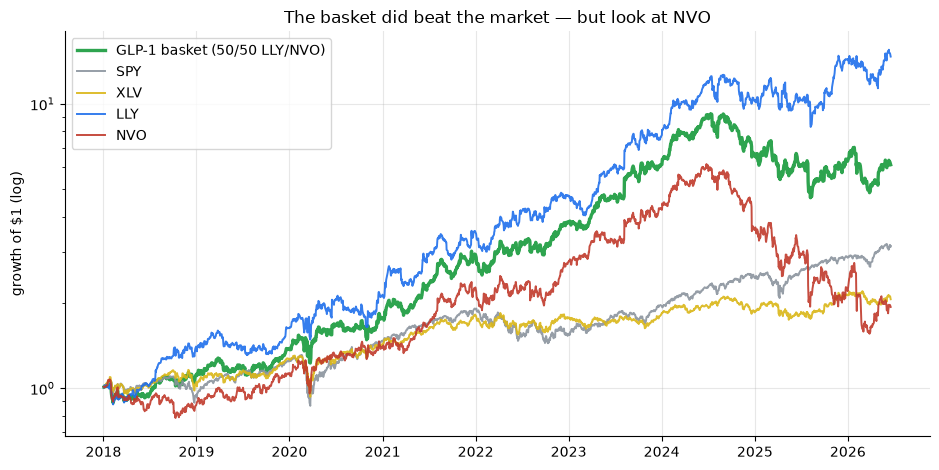

basket total 511%  vs SPY 216%  XLV 105%  (LLY 1367%, NVO 93%)


In [2]:
names = ['LLY','NVO','XLV','SPY']
if HAVE_REAL:
    curves = {n: (1+RET[n]).cumprod() for n in names}
    bk = (1+BK).cumprod(); idx = bk.index
else:
    # frozen-total fallback: a smooth curve to each name's known total return
    idx = np.arange(R['n']); fin = {'LLY':R['lly_tot'],'NVO':R['nvo_tot'],'XLV':R['xlv_tot'],'SPY':R['spy_tot']}
    curves = {n: 1+(fin[n]/100)*(np.arange(R['n'])/(R['n']-1)) for n in names}
    bk = 1+(R['bk_tot']/100)*(np.arange(R['n'])/(R['n']-1))
fig, ax = plt.subplots(figsize=(9.5,4.8))
ax.plot(idx, bk, c=GREEN, lw=2.4, label='GLP-1 basket (50/50 LLY/NVO)')
for n,c in [('SPY',GREY),('XLV',AMBER),('LLY','#1f6feb'),('NVO',RED)]:
    ax.plot(idx, curves[n], c=c, lw=1.4, alpha=.9, label=n)
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.set_title('The basket did beat the market — but look at NVO')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print(f"basket total {R['bk_tot']:.0f}%  vs SPY {R['spy_tot']:.0f}%  XLV {R['xlv_tot']:.0f}%  (LLY {R['lly_tot']:.0f}%, NVO {R['nvo_tot']:.0f}%)")

The basket (green) ends well above SPY and XLV — total return **511%** vs SPY's **216%**. But notice the two ingredients are wildly different: LLY is the rocket (**1367%**), while **NVO** (red) round-tripped — up, then **-69% down from its peak**. A 50/50 'basket' of those two isn't a diversified theme; it's one winner dragging one loser.

**Second: is the basket really the theme — or one stock?** Each name's edge over the market once we strip out general market moves (a higher bar passes the test).

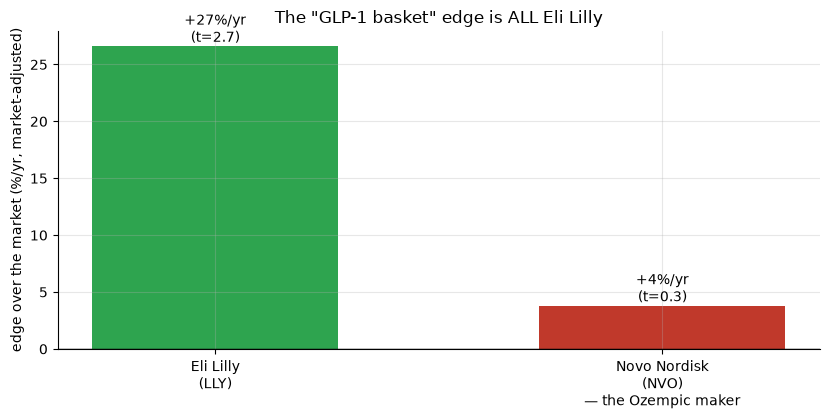

LLY edge +26.6%/yr (t=2.66)   NVO edge +3.8%/yr (t=0.35)


In [3]:
if HAVE_REAL:
    aL = st.market_model(RET['LLY'], RET['SPY']); aN = st.market_model(RET['NVO'], RET['SPY'])
    laL, taL = aL['alpha_ann']*100, aL['t_alpha']; laN, taN = aN['alpha_ann']*100, aN['t_alpha']
else:
    laL, taL, laN, taN = R['lly_alpha'], R['lly_ta'], R['nvo_alpha'], R['nvo_ta']
fig, ax = plt.subplots(figsize=(8.4,4.3))
bars = ax.bar(['Eli Lilly\n(LLY)','Novo Nordisk\n(NVO)\n— the Ozempic maker'], [laL, laN],
              color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('edge over the market (%/yr, market-adjusted)')
ax.set_title('The "GLP-1 basket" edge is ALL Eli Lilly')
for b,(v,t) in zip(bars, [(laL,taL),(laN,taN)]):
    ax.annotate(f'{v:+.0f}%/yr\n(t={t:.1f})', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'LLY edge {laL:+.1f}%/yr (t={taL:.2f})   NVO edge {laN:+.1f}%/yr (t={taN:.2f})')

There it is. **Lilly** carries a real market-beating edge (~27%/yr, *t*=2.7). **Novo** — *the company that makes Ozempic itself* — adds **~nothing** (4%/yr, *t*=0.3, indistinguishable from zero). The "weight-loss-drug basket" is one drug-maker with a passenger. Calling it a *theme* hides that you're really making a single-stock bet on Lilly.

**Third — the kicker: did it work *during* the boom?** Split at the start of 2023, when the Ozempic story went mainstream. How much did the basket beat the market in each half?

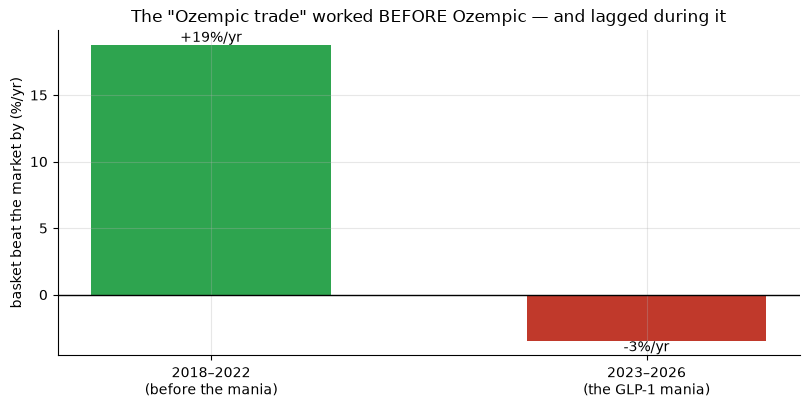

before 2023: +18.8%/yr   during 2023-26 mania: -3.5%/yr


In [4]:
if HAVE_REAL:
    pre = RET.index < '2023-01-01'; post = ~pre
    exb = (BK - RET['SPY'])
    pre_ex = exb[pre].mean()*252*100; post_ex = exb[post].mean()*252*100
else:
    pre_ex, post_ex = R['pre_ex'], R['post_ex']
fig, ax = plt.subplots(figsize=(8.2,4.2))
bars = ax.bar(['2018–2022\n(before the mania)','2023–2026\n(the GLP-1 mania)'],
              [pre_ex, post_ex], color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('basket beat the market by (%/yr)')
ax.set_title('The "Ozempic trade" worked BEFORE Ozempic — and lagged during it')
for b,v in zip(bars,[pre_ex,post_ex]):
    ax.annotate(f'{v:+.0f}%/yr',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'before 2023: {pre_ex:+.1f}%/yr   during 2023-26 mania: {post_ex:+.1f}%/yr')

The trade out-ran the market by **+19%/yr** *before* 2023 — and then **trailed** it by **-4%/yr** *during* the very weight-loss-drug boom it's named after. By the time it was a famous named trade, the easy part was already over. That's the classic shape of a theme you hear about *after* it has happened.

## 5 · The verdict

- **Signal — Weak.** The basket beat the market, but the *edge* over SPY isn't statistically solid (*t*≈1.1); only vs the healthcare sector is it borderline — and even that is fragile.
- **Tradability — Mirage.** It's a **two-stock** bet with a **−49%** drawdown riding one product cycle. Costs aren't the problem; concentration is. That's beta to a story, not an edge you can scale.
- **Two stocks and a story? — Misattributed.** The edge is **all Lilly**; Novo, the Ozempic maker, contributed none and is 69% off its high — and the basket *lagged* during the actual boom.

## 6 · Could you actually trade it? — the risk you'd really run

Forget costs (they're a rounding error here). The real question for a *two-name* bet is: how deep a hole did it dig you on the way? Worst peak-to-trough drop of each:

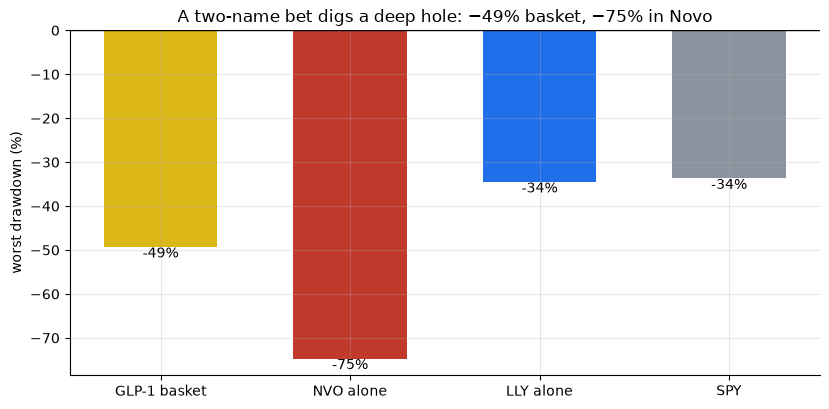

basket maxDD -49%   NVO -75%   LLY -34%   SPY -34%


In [5]:
labels = ['GLP-1 basket','NVO alone','LLY alone','SPY']
dds = [R['bk_dd'], R['nvo_dd'], R['lly_dd'], R['spy_dd']]
fig, ax = plt.subplots(figsize=(8.4,4.2))
bars = ax.bar(labels, dds, color=[AMBER, RED, '#1f6feb', GREY], width=.6)
ax.axhline(0,c='k',lw=1); ax.set_ylabel('worst drawdown (%)')
ax.set_title('A two-name bet digs a deep hole: −49% basket, −75% in Novo')
for b,v in zip(bars,dds): ax.annotate(f'{v:.0f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='top')
plt.tight_layout(); plt.show()
print(f"basket maxDD {R['bk_dd']:.0f}%   NVO {R['nvo_dd']:.0f}%   LLY {R['lly_dd']:.0f}%   SPY {R['spy_dd']:.0f}%")

To 'ride the theme' you had to sit through a **-49%** basket drawdown — and if you'd leaned toward the actual Ozempic maker, a **-75%** one in Novo. A diversified *edge* doesn't do that; a concentrated *bet* does. There's no cost trick that turns two correlated single stocks into a scalable strategy — the risk *is* the product.

## 7 · Going further 🚪

- **Broaden the basket honestly.** Add the 'GLP-1 losers' (food, dialysis, insulin-pump names) and the obesity-drug ETFs — does a *diversified* theme survive, or does it still collapse to Lilly?
- **Pick the date *without* hindsight.** We chose LLY+NVO knowing they won. Re-run it choosing the basket as of 2018 from *all* the GLP-1 hopefuls of the day — the honest version of the trade.
- **The general lesson.** Any 'theme basket' named after the product whose makers already 10×'d is selection by construction. The cheap part is usually gone by the time it has a name.

*Think the theme is broader than one stock? Build the diversified GLP-1 basket and show its market-adjusted edge clears *t* = 2 — then check it isn't still just Lilly in disguise.*